In [1]:
from dotenv import load_dotenv
from langchain_core.output_parsers import StrOutputParser
from langchain_teddynote import logging as langsmith_logging

# API KEY 정보로드
load_dotenv()
# Langsmith 로깅 설정
langsmith_logging.langsmith("RAG-EXAMPLE-LANGGRAPH")

LangSmith 추적을 시작합니다.
[프로젝트명]
RAG-EXAMPLE-LANGGRAPH


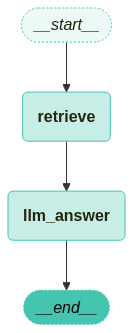

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


기존 벡터스토어를 로드했습니다: ./data/chroma
[DEBUG] embed_query() 호출 → 모델: solar-embedding-1-large-query

🔄 Node: llm_answer 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
삼성전자가 개발한 생성형 AI '삼성 가우스'는 온디바이스에서 작동하며, 언어, 코드, 이미지의 3개 모델로 구성되어 있습니다. 이 AI는 사용자 정보 유출 위험이 없고, 다양한 제품에 단계적으로 탑재될 예정입니다. 언어 모델은 메일 작성, 문서 요약, 번역을 지원하며, 코드 모델은 대화형 인터페이스를 통해 소프트웨어 개발에 최적화되어 있습니다. 이미지 모델은 창의적인 이미지 생성과 저해상도 이미지를 고해상도로 변환하는 기능을 제공합니다.

**Source**
- ./data/SPRI_AI_Brief_2023년12월호_F.pdf (page 13)

In [5]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_teddynote.messages import messages_to_history
from utils.utils import format_docs
from langchain_openai import ChatOpenAI
from langchain_core.prompts import load_prompt
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from operator import itemgetter
from langchain import hub

from langgraph.graph import END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_teddynote.graphs import visualize_graph
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import invoke_graph, stream_graph, random_uuid

# utils 모듈에서 모든 필요한 기능들을 import
from example.utils import (
    load_pdf_with_toc_filter,
    DebugUpstageAsymmetricEmbeddings,
    get_or_create_vector_store
)

# 전역 변수로 체인을 한 번만 생성
_rag_chain = None


# GraphState 상태 정의
class GraphState(TypedDict):
    question: Annotated[str, "Question"]  # 질문
    context: Annotated[str, "Context"]  # 문서의 검색 결과
    answer: Annotated[str, "Answer"]  # 답변
    messages: Annotated[str, add_messages]  # 메시지 (누적되는 list)


def create_rag_chain():
    """RAG용 체인을 생성하는 함수"""
    # ChatOpenAI 사용
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    # 프롬프트 로드 (두 가지 방법 중 선택)
    # 방법 1: 로컬 파일 사용
    # prompt = load_prompt("example/prompts/rag-prompts.yaml")

    # 방법 2: 허브에서 가져오기
    prompt = hub.pull("teddynote/rag-prompt-chat-history")

    # 체인 생성
    chain = {
                "question": itemgetter("question"),
                "context": itemgetter("context"),
                "chat_history": itemgetter("chat_history"),
            } | prompt | llm | StrOutputParser()

    return chain


def get_rag_chain():
    """체인을 싱글톤 패턴으로 관리"""
    global _rag_chain
    if _rag_chain is None:
        _rag_chain = create_rag_chain()

    return _rag_chain


# 문서 검색 노드
def retrieve_document(state: GraphState) -> GraphState:
    # db 설정 정보
    embeddings = DebugUpstageAsymmetricEmbeddings()
    db = get_or_create_vector_store(embedding=embeddings)

    # 질문을 상태에서 가져옵니다.
    latest_question = state["question"]

    # 문서에서 검색하여 관련성 있는 문서를 찾습니다.
    retrieved_docs = db.similarity_search(latest_question)

    # 검색된 문서를 형식화합니다. (프롬프트 입력으로 넣어주기 위함)
    retrieved_docs = format_docs(retrieved_docs)

    # 검색된 문서를 context 키에 저장합니다.
    return {"context": retrieved_docs}


# 답변 생성 노드
def llm_answer(state: GraphState) -> GraphState:
    # 질문을 상태에서 가져옵니다.
    latest_question = state["question"]

    # 검색된 문서를 상태에서 가져옵니다.
    context = state["context"]

    # chain 호출
    chain = get_rag_chain()

    # 체인을 호출하여 답변을 생성합니다.
    response = chain.invoke(
        {
            "question": latest_question,
            "context": context,
            "chat_history": messages_to_history(state["messages"])
        }
    )

    # 생성된 답변, (유저의 질문, 답변) 메시지를 상태에 저장합니다.
    return {
        "answer": response,
        "messages": [("user", latest_question), ("assistant", response)]
    }


# 그래프 생성
workflow = StateGraph(GraphState)

# 노드 정의
workflow.add_node("retrieve", retrieve_document)
workflow.add_node("llm_answer", llm_answer)

# 엣지 정의
workflow.add_edge("retrieve", "llm_answer")
workflow.add_edge("llm_answer", END)

# 그래프 진입점 설정
workflow.set_entry_point("retrieve")

# 체크포인터 설정
memory = MemorySaver()

# 컴파일
app = workflow.compile(checkpointer=memory)
# 컴파일한 그래프 시각화
visualize_graph(app)

# config 설정(재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})
# 질문 입력
inputs = GraphState(question="삼성전자에서 개발한 생성형AI에 대해 설명해줘.")
# 그래프 실행
# invoke_graph(app, inputs, config, ["llm_answer"])
stream_graph(app, inputs, config)